# Diffusion policies for complex continuous control

Research question: To what extent can a diffusion policy improve imitation learning for complex continuous control in `LunarLanderContinuous-v3`, compared with standard behavior cloning and a discretized DQN baseline?

The notebook evaluates three learned controllers and one demonstration expert:

1. a from-scratch DQN with a discretized two-dimensional action space,
2. a continuous SAC expert used only to generate demonstrations,
3. an MLP behavior-cloning student, and
4. a diffusion-policy student trained on the same demonstrations as the MLP.

Training the MLP and diffusion students on the same demonstrations lets us compare their action-generation methods directly.

### Glossary

- State / observation: the eight numbers that describe the lander at the current instant.
- Action: the two engine-control values sent to the environment.
- Reward: the immediate feedback from one environment step. Return is the sum of rewards over a whole episode.
- Episode: one complete attempt, from `reset()` until termination or the time limit.
- Policy: a rule or model that chooses actions from states.
- Q-value: DQN's estimate of the future return from taking a particular action in a state.
- Replay buffer: stored past transitions sampled in random minibatches during DQN training.
- Target network: a delayed copy of the Q-network used to make DQN targets less unstable.
- Expert demonstration: a state-action trajectory generated by the trained SAC controller.
- Behavior cloning: supervised learning that imitates expert actions without using rewards directly.
- Action chunk: several future actions predicted together instead of one action at a time.
- Diffusion timestep: the chosen noise level in the artificial denoising process, not a Gym environment step.
- Inference: using a trained model to choose actions. No learning occurs during inference.

In [1]:
from collections import deque
from pathlib import Path
import random
import sys
import time

import numpy as np

# Must run before gymnasium/stable_baselines3 import: both reference the
# removed np.bool8 alias internally, so this patch has to land first.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
sys.modules.setdefault("tensorflow", None)

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image, display
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import (
    EvalCallback,
    StopTrainingOnRewardThreshold,
)

In [2]:
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Every tensor and model involved in one operation must be on the same device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("checkpoints/paper_lunar_lander")
OUTPUT_DIR = Path("generated-gifs-lunar-lander")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"device={device}")

device=cuda


## 1. Environment and controlled comparison

`LunarLanderContinuous-v3` has an eight-dimensional observation and a two-dimensional continuous action. The first action controls the main engine, while the second controls the side engines. Both values lie in `[-1, 1]`. The observation is an eight-number vector rather than an image. It contains position, velocity, angle, angular velocity, and leg-contact information.

`LunarLanderContinuous-v3` was chosen over a single-joint benchmark like `Pendulum-v1` because its action space is two-dimensional instead of one: the main engine and the two side engines have to be commanded together, and a good landing depends on coordinating both at once. That matters for the paper's hypothesis that a diffusion policy's edge over simpler imitation baselines grows with action-space dimensionality. A one-dimensional control problem doesn't give a diffusion model much chance to show any benefit from modeling joint, correlated actions. LunarLander is the step up in action complexity from the earlier Pendulum pilot, used here to check whether that predicted advantage shows up once the policy has to output more than one coordinated value per decision.

Gymnasium starts an episode with `observation, info = env.reset(...)`. Each `env.step(action)` returns `(next_observation, reward, terminated, truncated, info)`. `terminated` means that the environment reached a terminal condition such as landing or crashing. `truncated` usually means that an outside limit, such as the maximum episode length, ended the episode. Both stop the interaction loop, but this notebook removes DQN's future-value bootstrap only for a genuine terminal state.

For DQN, each action dimension is divided into five bins. Their Cartesian product gives 25 joint actions. In general, `K` bins across `d` dimensions create `K^d` joint actions, which is why DQN discretization scales poorly. The bins are only an approximation for DQN; the Gym environment still receives a continuous action containing two numbers.

In [3]:
ENV_ID = "LunarLanderContinuous-v3"
env = gym.make(ENV_ID)
# reset() returns (observation, info)
observation, _ = env.reset(seed=SEED)

# observation=(8,), action=(2,).
STATE_DIM = int(env.observation_space.shape[0])
ACTION_DIM = int(env.action_space.shape[0])
ACTION_LOW = env.action_space.low.astype(np.float32)
ACTION_HIGH = env.action_space.high.astype(np.float32)

print("observation shape:", observation.shape)
print("action shape:", env.action_space.shape)
print("action bounds:", ACTION_LOW, ACTION_HIGH)
env.close()

observation shape: (8,)
action shape: (2,)
action bounds: [-1. -1.] [1. 1.]


## 2. Discretized DQN baseline

DQN is a value-based method. For each state, the network outputs one Q-value for every discrete action and selects the action with the largest Q-value during greedy evaluation. Ordinary DQN cannot output arbitrary continuous actions, so this baseline uses 25 fixed engine combinations. That restriction matters when comparing it with the continuous policies.

The implementation uses the standard DQN components: an online Q-network that is optimized during training, a periodically synchronized target network, replay memory, epsilon-greedy exploration, and a Huber temporal-difference loss. The temporal-difference target combines the immediate reward with the target network's estimate of future return.

In [4]:
N_ACTION_BINS = 5
one_dimensional_bins = np.linspace(-1.0, 1.0, N_ACTION_BINS, dtype=np.float32)
# This is a Cartesian product, not five total actions: 5 main-engine values x 5 side-engine values = 25.
DQN_ACTIONS = np.array(
    np.meshgrid(one_dimensional_bins, one_dimensional_bins)
).T.reshape(-1, ACTION_DIM).astype(np.float32)
N_DISCRETE_ACTIONS = len(DQN_ACTIONS)
print(f"{N_ACTION_BINS} bins per dimension -> {N_DISCRETE_ACTIONS} joint actions")


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_count, hidden=256):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_count),
        )

    def forward(self, states):
        # (batch, 8 states) -> (batch, 25 Q-values).
        return self.network(states)


class ReplayBuffer:
    def __init__(self, capacity):
        # Use a queue to automatically discard the oldest experience when the buffer is full.
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        # `action` is the integer bin index here, not the two-value Gym action.
        self.buffer.append((state, action, reward, next_state, terminated))

    def sample(self, batch_size):
        # Random batches reduce the correlation between consecutive environment steps.
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, terminated = map(np.array, zip(*batch))
        return (
            torch.as_tensor(states, dtype=torch.float32, device=device),
            torch.as_tensor(actions, dtype=torch.long, device=device),
            torch.as_tensor(rewards, dtype=torch.float32, device=device),
            torch.as_tensor(next_states, dtype=torch.float32, device=device),
            torch.as_tensor(terminated, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)

5 bins per dimension -> 25 joint actions


In [5]:
# Hyperparameters for DQN
DQN_GAMMA = 0.99 # Gamma is the discount factor for future rewards; it balances immediate vs. long-term rewards.
DQN_LR = 3e-4 # Learning rate for the optimizer; it controls how much to adjust the model in response to the estimated error each time the model weights are updated.
DQN_BATCH_SIZE = 256 # Number of transitions to sample from the replay buffer for each training step.
DQN_BUFFER_CAPACITY = 200_000 # Maximum number of transitions to store in the replay buffer.
DQN_REPLAY_WARMUP = 5_000 # Number of initial steps to populate the replay buffer before training.
DQN_TARGET_SYNC = 1_000 # Number of training steps between updates to the target network.
DQN_EPS_START, DQN_EPS_END = 1.0, 0.05 # Initial and final values for the epsilon-greedy exploration strategy.
DQN_EPS_DECAY_STEPS = 150_000 # Number of steps over which to decay epsilon from its initial value to its final value.
MAX_DQN_EPISODES = 1_200 # Maximum number of episodes to train the DQN.
DQN_EVAL_EVERY = 25 # Evaluate the DQN every N training steps.
DQN_EVAL_EPISODES = 10 # Number of episodes to evaluate the DQN.
DQN_STOP_RETURN = 200.0 # Return threshold for early stopping.
DQN_STOP_PATIENCE = 3 # Number of evaluations to wait before stopping if no improvement.
DQN_PATH = CHECKPOINT_DIR / "discretized_dqn.pt"
RETRAIN_DQN = False

online_q = QNetwork(STATE_DIM, N_DISCRETE_ACTIONS).to(device)
target_q = QNetwork(STATE_DIM, N_DISCRETE_ACTIONS).to(device)
target_q.load_state_dict(online_q.state_dict()) # Load the weights from the online Q-network to the target Q-network to ensure they start with the same parameters.
target_q.eval()
dqn_optimizer = torch.optim.Adam(online_q.parameters(), lr=DQN_LR)
replay = ReplayBuffer(DQN_BUFFER_CAPACITY)


def dqn_epsilon(step):
    # Epsilon is the probability of a random exploratory action (explore-exploit tradeoff); it decays from 1.0 to 0.05.
    fraction = min(1.0, step / DQN_EPS_DECAY_STEPS)
    return DQN_EPS_START + fraction * (DQN_EPS_END - DQN_EPS_START)


def dqn_action_index(state, step=0, greedy=False):
    # greedy=True disables random exploration and is required for fair evaluation.
    if not greedy and random.random() < dqn_epsilon(step):
        return random.randrange(N_DISCRETE_ACTIONS)
    # Action selection is inference, so PyTorch does not need a gradient graph.
    with torch.no_grad():
        state_tensor = torch.as_tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        return int(online_q(state_tensor).argmax(dim=1).item())


def dqn_train_step():
    if len(replay) < max(DQN_BATCH_SIZE, DQN_REPLAY_WARMUP):
        return None
    states, actions, rewards, next_states, terminated = replay.sample(DQN_BATCH_SIZE)
    # `gather` keeps only the Q-value of the action actually taken in each transition.
    predicted = online_q(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    # Targets are treated as fixed labels; gradients must not flow through target_q.
    with torch.no_grad():
        next_values = target_q(next_states).max(dim=1).values
        # A true terminal state has no future return. Truncation is deliberately allowed to bootstrap.
        targets = rewards + DQN_GAMMA * (1.0 - terminated) * next_values
    # Huber (smooth L1) loss is less sensitive to large TD errors than squared error.
    loss = F.smooth_l1_loss(predicted, targets)
    dqn_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(online_q.parameters(), 10.0)
    dqn_optimizer.step()
    return float(loss.item())


def evaluate_dqn(n_episodes, seed_start=30_000):
    evaluation_env = gym.make(ENV_ID)
    returns = []
    for episode in range(n_episodes):
        state, _ = evaluation_env.reset(seed=seed_start + episode)
        done = False
        episode_return = 0.0
        while not done:
            index = dqn_action_index(state, greedy=True)
            state, reward, terminated, truncated, _ = evaluation_env.step(
                DQN_ACTIONS[index]
            )
            episode_return += reward
            done = terminated or truncated
        returns.append(episode_return)
    evaluation_env.close()
    return np.asarray(returns, dtype=np.float32)

In [6]:
dqn_episode_returns = []
dqn_eval_history = []

# Keep RETRAIN_DQN=False to reuse the checkpoint; True starts a fresh expensive run.
if DQN_PATH.exists() and not RETRAIN_DQN:
    # weights_only=False: this checkpoint is our own, trusted file, and its saved
    # episode returns carry numpy scalar types that weights_only=True now rejects.
    checkpoint = torch.load(DQN_PATH, map_location=device, weights_only=False)
    online_q.load_state_dict(checkpoint["model_state"])
    target_q.load_state_dict(checkpoint["model_state"])
    dqn_episode_returns = checkpoint.get("episode_returns", [])
    dqn_eval_history = checkpoint.get("eval_history", [])
    print(f"loaded DQN checkpoint: {DQN_PATH}")
else:
    training_env = gym.make(ENV_ID)
    environment_step = 0
    best_eval_return = -np.inf
    best_state = None
    stop_streak = 0

    for episode in range(MAX_DQN_EPISODES):
        state, _ = training_env.reset(seed=SEED + episode)
        done = False
        episode_return = 0.0

        while not done:
            index = dqn_action_index(state, environment_step)
            next_state, reward, terminated, truncated, _ = training_env.step(
                DQN_ACTIONS[index]
            )
            # Store `terminated`, not combined `done`, so a time-limit truncation may bootstrap.
            replay.push(state, index, reward, next_state, float(terminated))
            state = next_state
            episode_return += reward
            environment_step += 1
            dqn_train_step()

            # Copying every 1,000 steps keeps the target steadier than the constantly changing online network.
            if environment_step % DQN_TARGET_SYNC == 0:
                target_q.load_state_dict(online_q.state_dict())
            done = terminated or truncated

        # float(...) keeps this a plain Python float, not a numpy scalar, for future checkpoint loads.
        dqn_episode_returns.append(float(episode_return))

        if (episode + 1) % DQN_EVAL_EVERY == 0:
            evaluation_returns = evaluate_dqn(DQN_EVAL_EPISODES)
            mean_evaluation = float(evaluation_returns.mean())
            dqn_eval_history.append((episode + 1, mean_evaluation))
            print(
                f"DQN episode {episode + 1}/{MAX_DQN_EPISODES}: "
                f"eval={mean_evaluation:.1f}, eps={dqn_epsilon(environment_step):.3f}"
            )

            if mean_evaluation > best_eval_return:
                best_eval_return = mean_evaluation
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in online_q.state_dict().items()
                }
            stop_streak = stop_streak + 1 if mean_evaluation >= DQN_STOP_RETURN else 0
            # Early stopping requires three consecutive strong evaluations, not one lucky episode.
            if stop_streak >= DQN_STOP_PATIENCE:
                print("DQN early-stopping criterion reached.")
                break

    training_env.close()
    if best_state is not None:
        online_q.load_state_dict(best_state)
        target_q.load_state_dict(best_state)
    torch.save(
        {
            "model_state": online_q.state_dict(),
            "episode_returns": dqn_episode_returns,
            "eval_history": dqn_eval_history,
        },
        DQN_PATH,
    )
    print(f"saved DQN checkpoint: {DQN_PATH}")

loaded DQN checkpoint: checkpoints\paper_lunar_lander\discretized_dqn.pt


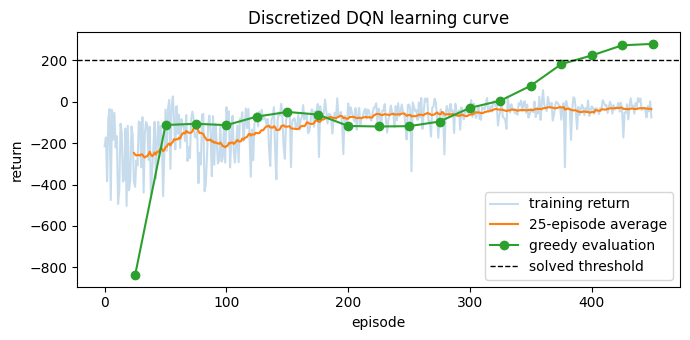

In [7]:
if dqn_episode_returns:
    plt.figure(figsize=(7, 3.5))
    plt.plot(dqn_episode_returns, alpha=0.25, label="training return")
    if len(dqn_episode_returns) >= 25:
        moving_average = np.convolve(
            dqn_episode_returns, np.ones(25) / 25, mode="valid"
        )
        plt.plot(range(24, len(dqn_episode_returns)), moving_average, label="25-episode average")
    if dqn_eval_history:
        evaluation_episodes, evaluation_means = zip(*dqn_eval_history)
        plt.plot(evaluation_episodes, evaluation_means, marker="o", label="greedy evaluation")
    plt.axhline(200, color="black", linestyle="--", linewidth=1, label="solved threshold")
    plt.xlabel("episode")
    plt.ylabel("return")
    plt.title("Discretized DQN learning curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3. Continuous SAC demonstration expert

Soft Actor-Critic (SAC) is an off-policy actor-critic algorithm for continuous actions. The actor is the policy that proposes an action, while the critic consists of value networks that judge actions. Off-policy means that SAC can learn from replayed experience collected by earlier versions of its policy.

SAC supplies the continuous demonstrations in this experiment. It is the teacher/data generator, not the main imitation-learning baseline. The MLP and diffusion students form the direct comparison because they learn from exactly the same demonstrations. Training stops early when a new best evaluation reaches the conventional return threshold of 200. This threshold is used to manage training time; it does not mean that every later episode will land.

In [8]:
SAC_PATH = CHECKPOINT_DIR / "sac_expert"
SAC_TIMESTEPS = 300_000
RETRAIN_SAC = False

# Stable-Baselines3 appends `.zip`; keep RETRAIN_SAC=False to load that saved expert.
if SAC_PATH.with_suffix(".zip").exists() and not RETRAIN_SAC:
    sac_expert = SAC.load(SAC_PATH, device=device)
    print(f"loaded SAC expert: {SAC_PATH}.zip")
else:
    sac_training_env = gym.make(ENV_ID)
    sac_evaluation_env = gym.make(ENV_ID)
    stop_on_solved = StopTrainingOnRewardThreshold(
        reward_threshold=200.0, verbose=1
    )
    # The callback evaluates periodically and may stop training after a sufficiently good new best model.
    evaluation_callback = EvalCallback(
        sac_evaluation_env,
        callback_on_new_best=stop_on_solved,
        best_model_save_path=str(CHECKPOINT_DIR / "sac_best"),
        log_path=str(CHECKPOINT_DIR / "sac_eval"),
        eval_freq=10_000,
        n_eval_episodes=10,
        # Deterministic evaluation removes SAC sampling noise when judging the checkpoint.
        deterministic=True,
    )
    sac_expert = SAC(
        "MlpPolicy",
        sac_training_env,
        learning_rate=3e-4,
        buffer_size=500_000,
        learning_starts=10_000,
        batch_size=256,
        gamma=0.99,
        tau=0.005,
        seed=SEED,
        device=device,
        verbose=1,
    )
    sac_expert.learn(total_timesteps=SAC_TIMESTEPS, callback=evaluation_callback)
    sac_expert.save(SAC_PATH)
    sac_training_env.close()
    sac_evaluation_env.close()
    print(f"saved SAC expert: {SAC_PATH}.zip")

loaded SAC expert: checkpoints\paper_lunar_lander\sac_expert.zip


## 4. Demonstration dataset and action chunks

A state-action demonstration records what the expert observed and what it did next. The notebook collects complete expert episodes and splits them by episode. This prevents adjacent states from the same trajectory from appearing in both the training and validation sets. That overlap would cause data leakage and could make the validation results look better than they are.

Each state is paired with the next eight two-dimensional actions, so each target has a shape of `(8, 2)`. Near the end of an episode, the final action is repeated until the chunk has eight actions. Both students use the same normalized states, action chunks, number of optimization steps, and minibatch size. The normalization statistics are calculated from the training set only; using validation statistics during training would leak information.

In [9]:
N_DEMONSTRATION_EPISODES = 200
TRAIN_EPISODE_FRACTION = 0.8
ACTION_HORIZON = 8

demonstration_env = gym.make(ENV_ID)
episode_samples = []
expert_returns = []

for episode in range(N_DEMONSTRATION_EPISODES):
    state, _ = demonstration_env.reset(seed=10_000 + episode)
    states, actions = [], []
    done = False
    episode_return = 0.0
    # 4/5 episodes use the deterministic expert; 1/5 retain SAC sampling variation.
    # This intentionally gives the students more than one valid control style.
    deterministic_expert = episode % 5 != 0

    while not done:
        action, _ = sac_expert.predict(state, deterministic=deterministic_expert)
        states.append(state.copy())
        actions.append(np.asarray(action, dtype=np.float32).copy())
        state, reward, terminated, truncated, _ = demonstration_env.step(action)
        episode_return += reward
        done = terminated or truncated

    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    chunks = []
    for start in range(len(actions)):
        # each target is 8 future actions x 2 engine controls = (8, 2).
        chunk = actions[start : start + ACTION_HORIZON]
        if len(chunk) < ACTION_HORIZON:
            # Padding repeats a valid final action; it does not add a fake zero action.
            padding = np.repeat(chunk[-1][None, :], ACTION_HORIZON - len(chunk), axis=0)
            chunk = np.concatenate([chunk, padding], axis=0)
        chunks.append(chunk)
    episode_samples.append((states, np.asarray(chunks, dtype=np.float32)))
    expert_returns.append(episode_return)

demonstration_env.close()
# Split whole episodes before concatenating transitions to prevent trajectory leakage.
split_episode = int(N_DEMONSTRATION_EPISODES * TRAIN_EPISODE_FRACTION)
train_states = np.concatenate([item[0] for item in episode_samples[:split_episode]])
train_action_chunks = np.concatenate([item[1] for item in episode_samples[:split_episode]])
validation_states = np.concatenate([item[0] for item in episode_samples[split_episode:]])
validation_action_chunks = np.concatenate([item[1] for item in episode_samples[split_episode:]])

# Fit normalization on training states only, then reuse it everywhere else.
state_mean = train_states.mean(axis=0, keepdims=True)
state_std = train_states.std(axis=0, keepdims=True) + 1e-6
train_states_normalized = (train_states - state_mean) / state_std
validation_states_normalized = (validation_states - state_mean) / state_std

# `as_tensor` converts NumPy arrays for PyTorch; all four tensors are placed on the chosen device.
train_states_tensor = torch.as_tensor(train_states_normalized, dtype=torch.float32, device=device)
train_chunks_tensor = torch.as_tensor(train_action_chunks, dtype=torch.float32, device=device)
validation_states_tensor = torch.as_tensor(validation_states_normalized, dtype=torch.float32, device=device)
validation_chunks_tensor = torch.as_tensor(validation_action_chunks, dtype=torch.float32, device=device)

print(f"train transitions: {len(train_states):,}")
print(f"validation transitions: {len(validation_states):,}")
print(f"expert return: {np.mean(expert_returns):.1f} +/- {np.std(expert_returns):.1f}")

train transitions: 61,250
validation transitions: 16,029
expert return: 230.5 +/- 70.2


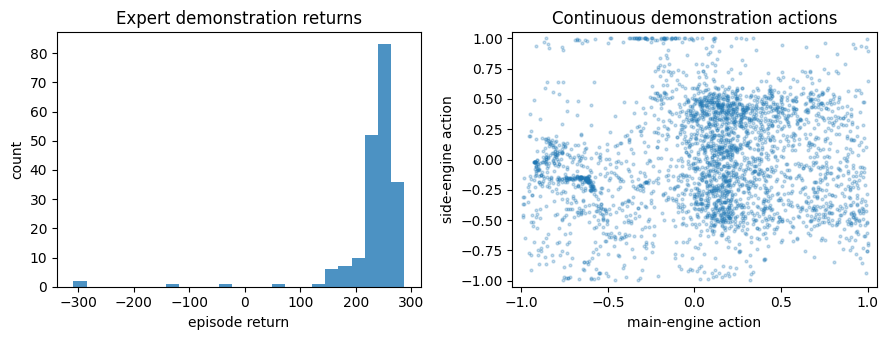

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(expert_returns, bins=25, color="tab:blue", alpha=0.8)
axes[0].set_title("Expert demonstration returns")
axes[0].set_xlabel("episode return")
axes[0].set_ylabel("count")
# `sample_actions` is defined here from the first action of every training chunk.
# [::20] below only thins points for readability; it does not affect training.
sample_actions = train_action_chunks[:, 0, :]
axes[1].scatter(sample_actions[::20, 0], sample_actions[::20, 1], s=4, alpha=0.25)
axes[1].set_xlim(-1.05, 1.05)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_xlabel("main-engine action")
axes[1].set_ylabel("side-engine action")
axes[1].set_title("Continuous demonstration actions")
fig.tight_layout()
plt.show()

## 5. Standard MLP behavior cloning

The imitation baseline is a multilayer perceptron (MLP) that maps the current normalized state directly to an eight-step action chunk. It is trained through supervised learning: the expert action chunk is the label, and mean-squared error measures the numerical difference between the predicted and demonstrated actions. The MLP does not use environment rewards during student training.

The final `Tanh` keeps each prediction in `[-1, 1]`, which matches the action bounds. During evaluation, the controller executes the first four of the eight predicted actions. It then observes the new state and replans. This receding-horizon design means that the controller does not commit to all eight actions after the environment has changed.

In [11]:
STUDENT_BATCH_SIZE = 256
STUDENT_TRAINING_STEPS = 20_000
STUDENT_LR = 3e-4
VALIDATE_EVERY = 500
MLP_PATH = CHECKPOINT_DIR / "mlp_behavior_clone.pt"
RETRAIN_MLP = False


class MLPBehaviorClone(nn.Module):
    def __init__(self, state_dim, horizon, action_dim, hidden=256):
        super().__init__()
        self.horizon = horizon
        self.action_dim = action_dim
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.Mish(),
            nn.Linear(hidden, hidden), nn.Mish(),
            nn.Linear(hidden, horizon * action_dim), nn.Tanh(),
        )

    def forward(self, states):
        # (batch, 8) -> flat (batch, 16) -> action chunks (batch, 8, 2).
        output = self.network(states)
        return output.reshape(-1, self.horizon, self.action_dim)


mlp_student = MLPBehaviorClone(STATE_DIM, ACTION_HORIZON, ACTION_DIM).to(device)
mlp_optimizer = torch.optim.Adam(mlp_student.parameters(), lr=STUDENT_LR)
mlp_training_losses, mlp_validation_losses = [], []

# Keep RETRAIN_MLP=False to load the best saved weights instead of retraining.
if MLP_PATH.exists() and not RETRAIN_MLP:
    checkpoint = torch.load(MLP_PATH, map_location=device, weights_only=True)
    mlp_student.load_state_dict(checkpoint["model_state"])
    mlp_training_losses = checkpoint.get("training_losses", [])
    mlp_validation_losses = checkpoint.get("validation_losses", [])
    print(f"loaded MLP student: {MLP_PATH}")
else:
    best_validation = np.inf
    best_state = None
    for step in range(1, STUDENT_TRAINING_STEPS + 1):
        # A minibatch is a random subset; it is cheaper than using all ~60k samples per update.
        indices = torch.randint(0, len(train_states_tensor), (STUDENT_BATCH_SIZE,), device=device)
        prediction = mlp_student(train_states_tensor[indices])
        # Behavior cloning treats the expert action chunk as the supervised target.
        loss = F.mse_loss(prediction, train_chunks_tensor[indices])
        mlp_optimizer.zero_grad()
        loss.backward()
        mlp_optimizer.step()
        mlp_training_losses.append(float(loss.item()))

        if step % VALIDATE_EVERY == 0:
            # Validation measures generalization; no parameter update or gradient graph is needed.
            with torch.no_grad():
                validation_loss = F.mse_loss(
                    mlp_student(validation_states_tensor), validation_chunks_tensor
                ).item()
            mlp_validation_losses.append((step, validation_loss))
            print(f"MLP step {step}: validation loss={validation_loss:.5f}")
            if validation_loss < best_validation:
                best_validation = validation_loss
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in mlp_student.state_dict().items()
                }
    if best_state is not None:
        mlp_student.load_state_dict(best_state)
    torch.save(
        {
            "model_state": mlp_student.state_dict(),
            "training_losses": mlp_training_losses,
            "validation_losses": mlp_validation_losses,
        },
        MLP_PATH,
    )

loaded MLP student: checkpoints\paper_lunar_lander\mlp_behavior_clone.pt


## 6. Diffusion-policy student

The diffusion student learns a conditional denoising problem. During training, a clean expert action chunk is mixed with Gaussian noise at a randomly selected diffusion timestep (noise level). The network receives the noisy chunk, the noise-level embedding, and the current normalized state. Its target is the exact noise added to the clean chunk.

There is no clean chunk during inference. Sampling starts with random noise and removes predicted noise over 30 reverse steps to produce an action chunk conditioned on the lander state. The process can produce different plausible action patterns, but it is stochastic and takes longer than one MLP forward pass. A diffusion timestep is an internal denoising index, not an environment timestep.

In [12]:
N_DIFFUSION_STEPS = 30
TIME_EMBEDDING_DIM = 32
ACTION_CHUNK_DIM = ACTION_HORIZON * ACTION_DIM
# `beta` controls added noise; `alpha_bar` records how much clean signal remains after repeated steps.
betas = torch.linspace(1e-4, 2e-2, N_DIFFUSION_STEPS, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def sinusoidal_embedding(timesteps, dimension=TIME_EMBEDDING_DIM):
    # Converts an integer noise level into smooth features the neural network can use.
    half = dimension // 2
    frequencies = torch.exp(
        -np.log(10_000) * torch.arange(half, device=device).float() / half
    )
    arguments = timesteps.float().unsqueeze(1) * frequencies.unsqueeze(0)
    return torch.cat([torch.sin(arguments), torch.cos(arguments)], dim=1)


class DiffusionPolicy(nn.Module):
    def __init__(self, state_dim, chunk_dim, hidden=512):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim + chunk_dim + TIME_EMBEDDING_DIM, hidden), nn.Mish(),
            nn.Linear(hidden, hidden), nn.Mish(),
            nn.Linear(hidden, chunk_dim),
        )

    def forward(self, noisy_chunks, timesteps, states):
        # three conditioning inputs are concatenated; output is predicted noise (batch, 16).
        time_features = sinusoidal_embedding(timesteps)
        inputs = torch.cat([noisy_chunks, time_features, states], dim=1)
        return self.network(inputs)


diffusion_student = DiffusionPolicy(STATE_DIM, ACTION_CHUNK_DIM).to(device)
diffusion_optimizer = torch.optim.Adam(diffusion_student.parameters(), lr=STUDENT_LR)

In [13]:
DIFFUSION_PATH = CHECKPOINT_DIR / "diffusion_policy.pt"
RETRAIN_DIFFUSION = False
diffusion_training_losses, diffusion_validation_losses = [], []
# (samples, 8, 2) is flattened to (samples, 16) for the denoising MLP.
train_chunks_flat = train_chunks_tensor.reshape(len(train_chunks_tensor), -1)
validation_chunks_flat = validation_chunks_tensor.reshape(len(validation_chunks_tensor), -1)

# Keep RETRAIN_DIFFUSION=False to reuse the checkpoint; sampling still runs at evaluation.
if DIFFUSION_PATH.exists() and not RETRAIN_DIFFUSION:
    checkpoint = torch.load(DIFFUSION_PATH, map_location=device, weights_only=True)
    diffusion_student.load_state_dict(checkpoint["model_state"])
    diffusion_training_losses = checkpoint.get("training_losses", [])
    diffusion_validation_losses = checkpoint.get("validation_losses", [])
    print(f"loaded diffusion student: {DIFFUSION_PATH}")
else:
    best_validation = np.inf
    best_state = None
    for step in range(1, STUDENT_TRAINING_STEPS + 1):
        indices = torch.randint(0, len(train_states_tensor), (STUDENT_BATCH_SIZE,), device=device)
        states_batch = train_states_tensor[indices]
        clean_chunks = train_chunks_flat[indices]
        # Each item receives a random noise level, so one network learns all 30 denoising stages.
        timesteps = torch.randint(
            0, N_DIFFUSION_STEPS, (STUDENT_BATCH_SIZE,), device=device
        )
        noise = torch.randn_like(clean_chunks)
        alpha_bar = alpha_bars[timesteps].unsqueeze(1)
        # Forward diffusion: retain some clean signal and add a known Gaussian-noise sample.
        noisy_chunks = (
            torch.sqrt(alpha_bar) * clean_chunks
            + torch.sqrt(1.0 - alpha_bar) * noise
        )
        predicted_noise = diffusion_student(noisy_chunks, timesteps, states_batch)
        # The training label is the added noise, not the clean action chunk itself.
        loss = F.mse_loss(predicted_noise, noise)
        diffusion_optimizer.zero_grad()
        loss.backward()
        diffusion_optimizer.step()
        diffusion_training_losses.append(float(loss.item()))

        if step % VALIDATE_EVERY == 0:
            with torch.no_grad():
                # Validation uses a smaller random subset to save time 
                validation_count = min(4_096, len(validation_states_tensor))
                validation_indices = torch.arange(validation_count, device=device)
                validation_times = torch.randint(
                    0, N_DIFFUSION_STEPS, (validation_count,), device=device
                )
                validation_noise = torch.randn_like(
                    validation_chunks_flat[validation_indices]
                )
                validation_alpha_bar = alpha_bars[validation_times].unsqueeze(1)
                validation_noisy = (
                    torch.sqrt(validation_alpha_bar)
                    * validation_chunks_flat[validation_indices]
                    + torch.sqrt(1.0 - validation_alpha_bar) * validation_noise
                )
                validation_prediction = diffusion_student(
                    validation_noisy,
                    validation_times,
                    validation_states_tensor[validation_indices],
                )
                validation_loss = F.mse_loss(
                    validation_prediction, validation_noise
                ).item()
            diffusion_validation_losses.append((step, validation_loss))
            print(f"diffusion step {step}: validation loss={validation_loss:.5f}")
            if validation_loss < best_validation:
                best_validation = validation_loss
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in diffusion_student.state_dict().items()
                }
    # Save the best validation weights
    if best_state is not None:
        diffusion_student.load_state_dict(best_state)
    torch.save(
        {
            "model_state": diffusion_student.state_dict(),
            "training_losses": diffusion_training_losses,
            "validation_losses": diffusion_validation_losses,
        },
        DIFFUSION_PATH,
    )


# Sampling is inference only, hence this decorator disables gradients for the whole function.
@torch.no_grad()
def sample_diffusion_chunks(normalized_states):
    batch_size = normalized_states.shape[0]
    # Start from pure random noise, then denoise from timestep 29 down to 0.
    chunks = torch.randn(batch_size, ACTION_CHUNK_DIM, device=device)
    for timestep in reversed(range(N_DIFFUSION_STEPS)):
        times = torch.full(
            (batch_size,), timestep, dtype=torch.long, device=device
        )
        predicted_noise = diffusion_student(chunks, times, normalized_states)
        alpha = alphas[timestep]
        alpha_bar = alpha_bars[timestep]
        beta = betas[timestep]
        mean = (
            chunks - beta * predicted_noise / torch.sqrt(1.0 - alpha_bar)
        ) / torch.sqrt(alpha)
        chunks = mean + torch.sqrt(beta) * torch.randn_like(chunks) if timestep > 0 else mean
    # Clamp is a final safety check because Gym actions must remain inside [-1, 1].
    return chunks.clamp(-1.0, 1.0).reshape(
        batch_size, ACTION_HORIZON, ACTION_DIM
    )

loaded diffusion student: checkpoints\paper_lunar_lander\diffusion_policy.pt


## 7. Controlled evaluation

All policies are evaluated on the same 30 unseen random seeds, so each controller faces the same initial conditions. These episodes are used only for evaluation and are not added to the training data.

Episode return is the primary metric. Higher return and landing-success rate are better. The success flag is a project-specific heuristic: the episode must terminate with a positive final reward. Smoothness is the average size of the changes between consecutive action vectors. A lower value means that the controls changed less abruptly, but it does not necessarily mean that the controller performed the task better. Lower inference time means faster action selection.

In [14]:
# Chunk policies predict 8 actions but execute only 4 before observing and replanning.
EXECUTION_HORIZON = 4
N_EVALUATION_EPISODES = 30
EVALUATION_SEED_START = 50_000


def normalize_state(state):
    # Reuse training-set statistics; [None, :] adds the batch dimension expected by PyTorch.
    return ((state[None, :] - state_mean) / state_std).astype(np.float32)


class DQNController:
    def reset(self):
        pass

    def act(self, state):
        return DQN_ACTIONS[dqn_action_index(state, greedy=True)].copy()


class SACController:
    def reset(self):
        pass

    def act(self, state):
        action, _ = sac_expert.predict(state, deterministic=True)
        return np.asarray(action, dtype=np.float32)


class ChunkController:
    def __init__(self, model_type):
        self.model_type = model_type
        self.pending_actions = deque()

    def reset(self):
        self.pending_actions.clear()

    def act(self, state):
        if not self.pending_actions:
            # Receding horizon: create a new chunk only after the first four queued actions are used.
            normalized = torch.as_tensor(
                normalize_state(state), dtype=torch.float32, device=device
            )
            with torch.no_grad():
                if self.model_type == "mlp":
                    chunk = mlp_student(normalized)[0].cpu().numpy()
                elif self.model_type == "diffusion":
                    chunk = sample_diffusion_chunks(normalized)[0].cpu().numpy()
                else:
                    raise ValueError(self.model_type)
            self.pending_actions.extend(chunk[:EXECUTION_HORIZON])
        return np.asarray(self.pending_actions.popleft(), dtype=np.float32)


def evaluate_controller(controller, n_episodes=N_EVALUATION_EPISODES):
    evaluation_env = gym.make(ENV_ID)
    returns, successes, smoothness, inference_ms = [], [], [], []

    for episode in range(n_episodes):
        state, _ = evaluation_env.reset(seed=EVALUATION_SEED_START + episode)
        controller.reset()
        actions = []
        episode_return = 0.0
        successful_landing = False
        done = False

        while not done:
            started = time.perf_counter()
            # Clipping protects Gym from small out-of-range neural-network outputs.
            action = np.clip(controller.act(state), ACTION_LOW, ACTION_HIGH)
            inference_ms.append((time.perf_counter() - started) * 1_000)
            actions.append(action.copy())
            state, reward, terminated, truncated, _ = evaluation_env.step(action)
            episode_return += reward
            # This project-specific heuristic distinguishes positive terminal landings from crashes/timeouts.
            successful_landing = bool(terminated and reward > 0)
            done = terminated or truncated

        actions = np.asarray(actions)
        # Lower means consecutive 2-D actions changed less; it does not by itself mean a better landing.
        action_change = np.linalg.norm(np.diff(actions, axis=0), axis=1)
        returns.append(episode_return)
        successes.append(successful_landing)
        smoothness.append(float(action_change.mean()) if len(action_change) else 0.0)

    evaluation_env.close()
    return {
        "returns": np.asarray(returns, dtype=np.float32),
        "successes": np.asarray(successes, dtype=bool),
        "smoothness": np.asarray(smoothness, dtype=np.float32),
        "inference_ms": np.asarray(inference_ms, dtype=np.float32),
    }


controllers = {
    "Discretized DQN": DQNController(),
    "SAC expert": SACController(),
    "MLP behavior cloning": ChunkController("mlp"),
    "Diffusion policy": ChunkController("diffusion"),
}
# Every controller is evaluated with the identical seed range for a paired comparison.
evaluation_results = {
    name: evaluate_controller(controller) for name, controller in controllers.items()
}

Model comparison on unseen evaluation seeds
--------------------------------------------------------------------------------------------
model                    return (mean +/- sd)        success     smoothness   inference ms
Discretized DQN            233.4 +/-   86.5          86.7%         0.6819          0.306
SAC expert                 233.2 +/-   46.3          96.7%         0.1829          0.737
MLP behavior cloning       231.0 +/-   54.4          96.7%         0.1171          0.083
Diffusion policy           228.5 +/-   78.6          90.0%         0.5676          3.766


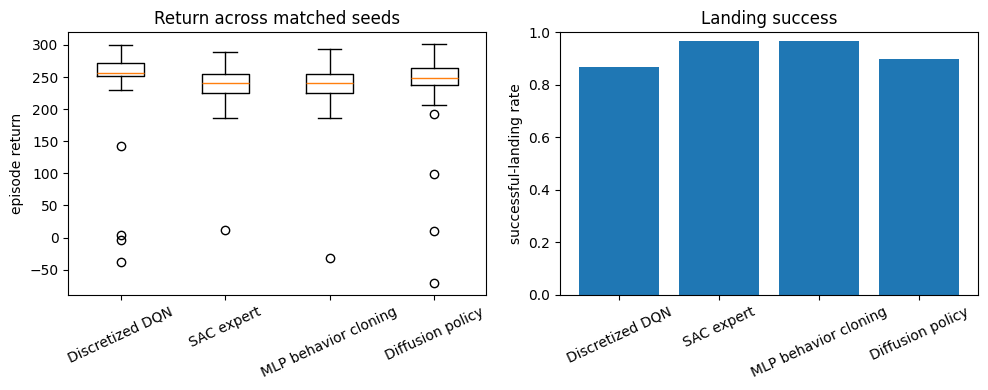

In [15]:
# Reading the table: return/success higher is better; smoothness/inference time lower is better.
print("Model comparison on unseen evaluation seeds")
print("-" * 92)
print(f"{'model':<24} {'return (mean +/- sd)':<24} {'success':>10} {'smoothness':>14} {'inference ms':>14}")
for name, result in evaluation_results.items():
    print(
        f"{name:<24} "
        f"{result['returns'].mean():7.1f} +/- {result['returns'].std():6.1f}      "
        f"{result['successes'].mean():9.1%} "
        f"{result['smoothness'].mean():14.4f} "
        f"{result['inference_ms'].mean():14.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = list(evaluation_results)
axes[0].boxplot(
    [evaluation_results[name]["returns"] for name in names],
    tick_labels=names,
)
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("episode return")
axes[0].set_title("Return across matched seeds")
axes[1].bar(
    names,
    [evaluation_results[name]["successes"].mean() for name in names],
)
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("successful-landing rate")
axes[1].set_title("Landing success")
fig.tight_layout()
plt.show()

### 7.1 Multi-seed diffusion re-run

The comparison above uses a single trained diffusion student, so its return could partly reflect one lucky or unlucky training seed rather than a genuine property of the method. Since the diffusion student is the model the paper's hypothesis depends on most, it is retrained from scratch with two additional random seeds (123 and 2024), independent of the original seed 42 run, while the demonstration dataset and evaluation seeds stay fixed. This isolates the effect of training-time randomness without re-running the whole pipeline for every controller.

In [16]:
def train_diffusion_seeded(seed, checkpoint_name):
    # Retrains an independent diffusion student from scratch under a different seed,
    # reusing the same demonstration tensors and hyperparameters as the main run.
    path = CHECKPOINT_DIR / checkpoint_name
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = DiffusionPolicy(STATE_DIM, ACTION_CHUNK_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=STUDENT_LR)

    if path.exists():
        checkpoint = torch.load(path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint["model_state"])
        print(f"loaded diffusion student ({checkpoint_name}), seed={seed}")
        return model

    best_validation = np.inf
    best_state = None
    for step in range(1, STUDENT_TRAINING_STEPS + 1):
        indices = torch.randint(0, len(train_states_tensor), (STUDENT_BATCH_SIZE,), device=device)
        states_batch = train_states_tensor[indices]
        clean_chunks = train_chunks_flat[indices]
        timesteps = torch.randint(0, N_DIFFUSION_STEPS, (STUDENT_BATCH_SIZE,), device=device)
        noise = torch.randn_like(clean_chunks)
        alpha_bar = alpha_bars[timesteps].unsqueeze(1)
        noisy_chunks = torch.sqrt(alpha_bar) * clean_chunks + torch.sqrt(1.0 - alpha_bar) * noise
        predicted_noise = model(noisy_chunks, timesteps, states_batch)
        loss = F.mse_loss(predicted_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % VALIDATE_EVERY == 0:
            with torch.no_grad():
                validation_count = min(4_096, len(validation_states_tensor))
                validation_indices = torch.arange(validation_count, device=device)
                validation_times = torch.randint(0, N_DIFFUSION_STEPS, (validation_count,), device=device)
                validation_noise = torch.randn_like(validation_chunks_flat[validation_indices])
                validation_alpha_bar = alpha_bars[validation_times].unsqueeze(1)
                validation_noisy = (
                    torch.sqrt(validation_alpha_bar) * validation_chunks_flat[validation_indices]
                    + torch.sqrt(1.0 - validation_alpha_bar) * validation_noise
                )
                validation_prediction = model(
                    validation_noisy, validation_times, validation_states_tensor[validation_indices]
                )
                validation_loss = F.mse_loss(validation_prediction, validation_noise).item()
            if validation_loss < best_validation:
                best_validation = validation_loss
                best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save({"model_state": model.state_dict()}, path)
    print(f"saved diffusion student ({checkpoint_name}), seed={seed}")
    return model


@torch.no_grad()
def sample_diffusion_chunks_with_model(model, normalized_states):
    # Same reverse process as sample_diffusion_chunks, generalized to any diffusion model instance.
    batch_size = normalized_states.shape[0]
    chunks = torch.randn(batch_size, ACTION_CHUNK_DIM, device=device)
    for timestep in reversed(range(N_DIFFUSION_STEPS)):
        times = torch.full((batch_size,), timestep, dtype=torch.long, device=device)
        predicted_noise = model(chunks, times, normalized_states)
        alpha = alphas[timestep]
        alpha_bar = alpha_bars[timestep]
        beta = betas[timestep]
        mean = (chunks - beta * predicted_noise / torch.sqrt(1.0 - alpha_bar)) / torch.sqrt(alpha)
        chunks = mean + torch.sqrt(beta) * torch.randn_like(chunks) if timestep > 0 else mean
    return chunks.clamp(-1.0, 1.0).reshape(batch_size, ACTION_HORIZON, ACTION_DIM)


class SeededChunkController(ChunkController):
    def __init__(self, model):
        super().__init__("diffusion")
        self.model = model

    def act(self, state):
        if not self.pending_actions:
            normalized = torch.as_tensor(normalize_state(state), dtype=torch.float32, device=device)
            with torch.no_grad():
                chunk = sample_diffusion_chunks_with_model(self.model, normalized)[0].cpu().numpy()
            self.pending_actions.extend(chunk[:EXECUTION_HORIZON])
        return np.asarray(self.pending_actions.popleft(), dtype=np.float32)

In [17]:
diffusion_seed_runs = {"seed=42 (main run)": evaluation_results["Diffusion policy"]["returns"]}

for seed, checkpoint_name in [(123, "diffusion_policy_seed123.pt"), (2024, "diffusion_policy_seed2024.pt")]:
    seeded_model = train_diffusion_seeded(seed, checkpoint_name)
    seeded_controller = SeededChunkController(seeded_model)
    seeded_result = evaluate_controller(seeded_controller)
    diffusion_seed_runs[f"seed={seed}"] = seeded_result["returns"]

print("Diffusion student return across independent training seeds")
print("-" * 60)
per_seed_means = []
for label, returns in diffusion_seed_runs.items():
    print(f"{label:<22} {returns.mean():7.1f} +/- {returns.std():6.1f}")
    per_seed_means.append(returns.mean())
per_seed_means = np.asarray(per_seed_means)
print("-" * 60)
print(f"{'across seeds':<22} {per_seed_means.mean():7.1f} +/- {per_seed_means.std():6.1f}")

loaded diffusion student (diffusion_policy_seed123.pt), seed=123
saved diffusion student (diffusion_policy_seed2024.pt), seed=2024
Diffusion student return across independent training seeds
------------------------------------------------------------
seed=42 (main run)       228.5 +/-   78.6
seed=123                 215.9 +/-   94.0
seed=2024                248.7 +/-   53.5
------------------------------------------------------------
across seeds             231.0 +/-   13.5


## 8. Qualitative rollout videos

The GIFs are a visual check for behaviour such as hovering, oscillation, or a hard landing that may not be obvious from one score. They are not evidence on their own because the displayed seed may be easier or harder than the other evaluation seeds.

Each frame is copied before the environment advances. Some renderers reuse the same image buffer, which can make an animation appear frozen or repeated if the frame is not copied. Every policy uses the same initial seed, so each video starts from the same state.

Discretized DQN


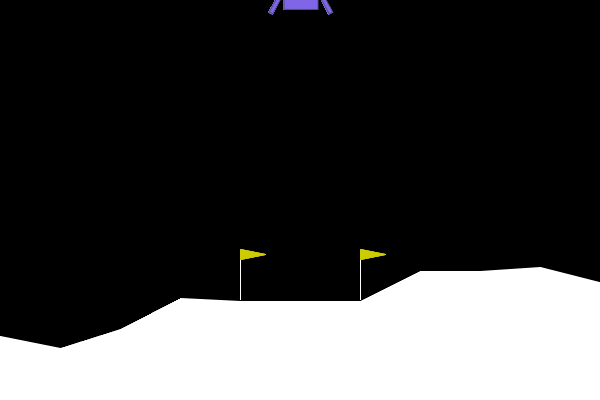

MLP behavior cloning


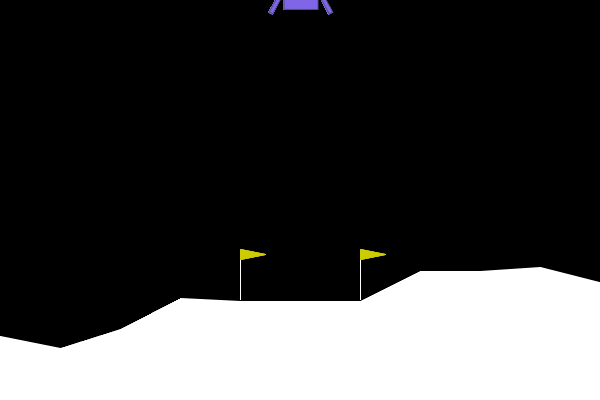

Diffusion policy


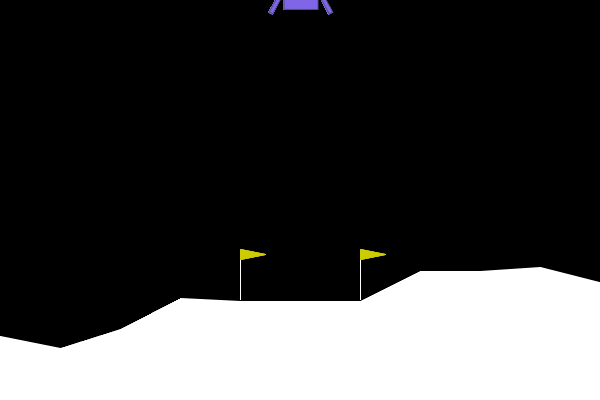

In [18]:
def save_rollout_gif(name, controller, seed=EVALUATION_SEED_START):
    render_env = gym.make(ENV_ID, render_mode="rgb_array")
    state, _ = render_env.reset(seed=seed)
    controller.reset()
    frames = []
    done = False
    while not done:
        # copy=True freezes this frame instead of retaining a renderer-owned buffer.
        frames.append(np.array(render_env.render(), copy=True))
        action = np.clip(controller.act(state), ACTION_LOW, ACTION_HIGH)
        state, _, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
    render_env.close()
    path = OUTPUT_DIR / f"{name.lower().replace(' ', '_')}.gif"
    imageio.mimsave(path, frames, duration=1 / 30, loop=0)
    return path


# Display GIFs of one matched seed per controller
for policy_name in ("Discretized DQN", "MLP behavior cloning", "Diffusion policy"):
    gif_path = save_rollout_gif(policy_name, controllers[policy_name])
    print(policy_name)
    display(Image(filename=str(gif_path)))

## 9. Interpretation and reporting guardrails

The hypothesis is supported only if the diffusion student improves materially over the MLP student on repeated-seed return or landing success. Beating the discretized DQN alone does not show an advantage caused by diffusion. DQN learns from rewards instead of demonstrations and loses action precision through discretization. SAC is also not the main imitation comparison because it generated the training data and uses a different objective.

The saved run should be reported using every metric. The diffusion policy has a higher landing-success rate than the discretized DQN, but it does not have a higher mean return or lower smoothness and latency values. The MLP behavior clone has the strongest results overall. The results show that diffusion is viable in this environment, but they do not show that it is generally better.

The negative and mixed results should be reported directly. The experiment is limited by the quality and coverage of the expert demonstrations, randomness in training and diffusion sampling, compounding behavior-cloning error, the restricted hyperparameter search, one trained checkpoint per method, and Lunar Lander's two action dimensions. Several complete training runs with independent seeds would be required for confidence intervals or significance claims about training variability. `paper_pendulum.ipynb` runs the same diffusion-vs-value-based comparison on a one-dimensional control problem (Pendulum-v1) and finds the diffusion student far behind its Double-DQN teacher there, which is consistent with diffusion needing more than one coordinated action dimension to be worth its cost.</cell id="interpretation-guardrails">
